# Exercise 5B

Classic dataset about geyser eruptions.

Each row represents an observed eruption of the Old Faithful Geyser in Yellowstone National Park. The eruptions column represents the duration of the eruption in minutes, and the waiting column represents the duration in minutes until the next eruption.

In this exercise, you will perform the following:
- Load and visualize a real 2D dataset
- Fit a Gaussian Mixture Model using sklearn
- Interpret GMM parameters (means, covariances, weights)
- Understand soft clustering via responsibilities
- Compare GMM with K-means
- Use log-likelihood and BIC for model selection

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [31]:
url = "https://gist.githubusercontent.com/hogwild/c2704a1ae38c0a36983bc13121050dac/raw/oldFaithfulGeyserDataset.csv?raw=True"

df = pd.read_csv(url)

1. Load and understand the dataset
- Inspect the first 5 rows using `.head()`
- Inspected the total number of rows and columns using `.info()`

In [32]:
# put your answer here
df.head()

,index,eruptions,waiting
0,1,3.600,79
1,2,1.800,54
2,3,3.333,74
3,4,2.283,62
4,5,4.533,85


2. Visualize the raw data
- Create a scatter plot of eruption duration vs waiting time.
- Label the axes.
- Describe the visible cluster structure.

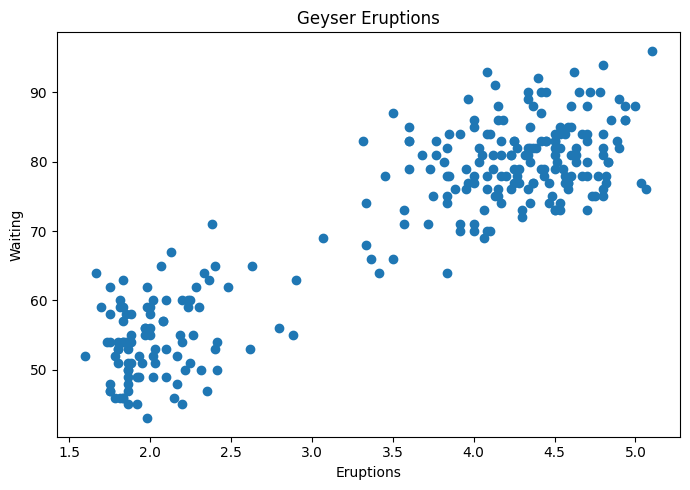

In [33]:
## put your answer here
plt.figure(figsize=(7,5))

# Scatter plot
plt.scatter(df['eruptions'],df['waiting'])
plt.xlabel('Eruptions')
plt.ylabel('Waiting')
plt.title('Geyser Eruptions')
plt.tight_layout()



2. Fit a 2-component GMM

Fit a GMM with:
- `n_components=2`
- `covariance_type="full"`
- `random_state=42`

In [34]:
# put your answer here
X = df[['eruptions','waiting']]

gmm = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42
)
gmm.fit(X)



GaussianMixture(n_components=2, random_state=42)

3. Inspect learned parameters

Print the following variables:
- Mixing coefficients `(gmm.weights_)`
- Means `(gmm.means_)`
- Covariance matrices `(gmm.covariances_)`

In [35]:
# put your answer here
print("Weights:", gmm.weights_)
print("Means:\n", gmm.means_)
print("Covariances:\n", gmm.covariances_)



Weights: [0.64407255 0.35592745]
Means:
 [[ 4.28977944 79.96953298]
 [ 2.03652149 54.47986018]]
Covariances:
 [[[ 0.16982046  0.93871793]
  [ 0.93871793 36.02497019]]

 [[ 0.06927449  0.43627723]
  [ 0.43627723 33.70493352]]]


4. Compute cluster responsibilities
- Use `predict_proba()` to compute responsibilities.
- Select a point near the overlap region.
- Print its responsibility values.

In [36]:
# put your answer here
responsibilities = gmm.predict_proba(X)

i = 100  # example index
print(responsibilities[i])

[1.66381527e-04 9.99833618e-01]


5. Hard assignment from GMM
- Use `.predict` to convert responsibilities into hard cluster labels.

In [37]:
# put your answer here
labels_gmm = gmm.predict(X)

6. Plot clusters found by GMM
- Plot the data colored by GMM cluster assignment.

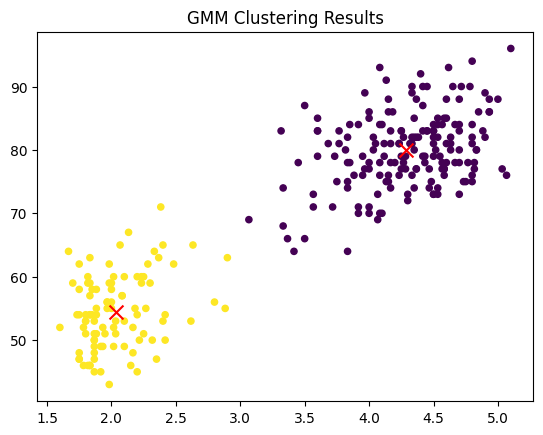

In [38]:
# put your answer here
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=labels_gmm, cmap="viridis", s=20)
plt.scatter(
    gmm.means_[:, 0],
    gmm.means_[:, 1],
    c="red",
    marker="x",
    s=100
)

plt.title("GMM Clustering Results")
plt.show()


7. Compare with K-means
- Fit K-means with k=2 and plot the result.

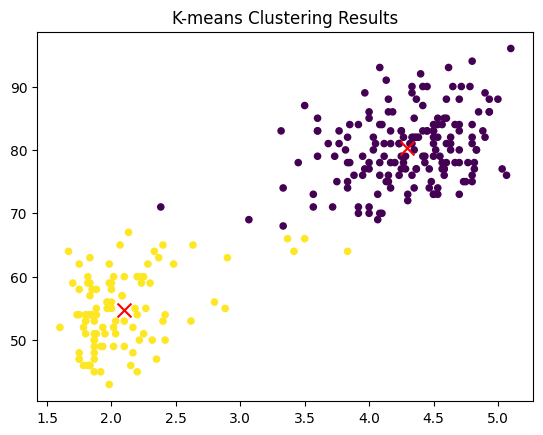

In [39]:
# put your answer here


kmeans = KMeans(n_clusters=2, random_state=42)
labels_km = kmeans.fit_predict(X)

plt.scatter(X.iloc[:,0], X.iloc[:,1], c=labels_km, cmap="viridis", s=20)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c="red",
    marker="x",
    s=100
)
plt.title("K-means Clustering Results")
plt.show()

8. Log-likelihood of the data
- Compute the average log-likelihood under the model.

In [40]:
# put your answer here
log_likelihood = gmm.score(X)
print("Average log-likelihood:", log_likelihood)

Average log-likelihood: -4.155382594740062


9. Model selection with BIC
- Fit GMMs with different numbers of components and compute BIC.

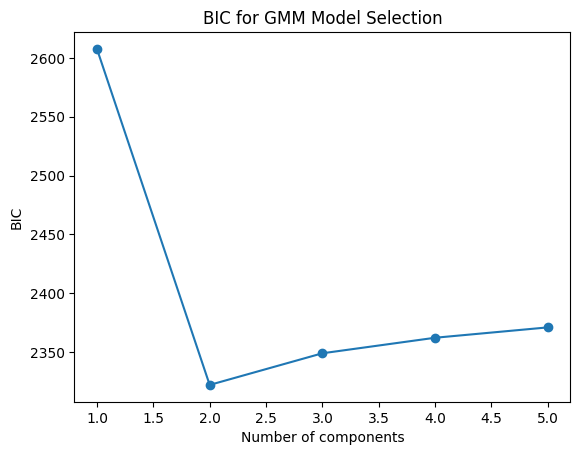

In [41]:
# put your answer here
bics = []
ks = range(1, 6)

for k in ks:
    gmm_k = GaussianMixture(n_components=k, random_state=42)
    gmm_k.fit(X)
    bics.append(gmm_k.bic(X))

plt.plot(ks, bics, marker='o')
plt.xlabel("Number of components")
plt.ylabel("BIC")
plt.title("BIC for GMM Model Selection")
plt.show()




10. Standardize the data
- Apply standardization to the dataset.
- Refit the GMM and compare results.

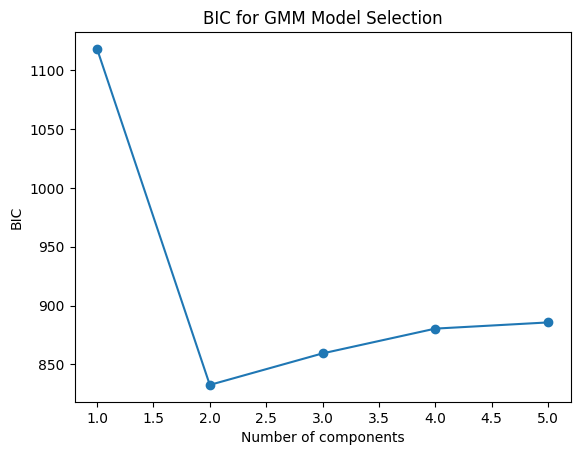

In [42]:
# put your answer here
from IPython.lib.display import join
from sklearn.preprocessing import StandardScaler

X_standardized = X.copy()

scaler_standard = StandardScaler()
X_standardized['eruptions'] = scaler_standard.fit_transform(X[['eruptions']])
X_standardized['waiting'] = scaler_standard.fit_transform(X[['waiting']])

bics = []
ks = range(1, 6)

for k in ks:
    gmm_k = GaussianMixture(n_components=k, random_state=42)
    gmm_k.fit(X_standardized)
    bics.append(gmm_k.bic(X_standardized))

plt.plot(ks, bics, marker='o')
plt.xlabel("Number of components")
plt.ylabel("BIC")
plt.title("BIC for GMM Model Selection")
plt.show()

